In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel('Metro_Interstate_Traffic_Volume.xlsx')

df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time')

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [2]:
# Aggregate numeric columns
df_num = df.groupby('date_time').mean(numeric_only=True)

# Keep categorical separately
df_cat = df.drop_duplicates('date_time')[['date_time','weather_main','holiday']]
df_cat = df_cat.set_index('date_time')

# Combine
df = df_num.join(df_cat)

df = df.sort_index()
print("Rows after dedup:", len(df))

Rows after dedup: 40575


In [3]:
# Holiday encoding
df['holiday'] = df['holiday'].fillna('None')

# One-hot encoding
df = pd.get_dummies(df, columns=['weather_main','holiday'], drop_first=True)

df.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,...,holiday_Independence Day,holiday_Labor Day,holiday_Martin Luther King Jr Day,holiday_Memorial Day,holiday_New Years Day,holiday_None,holiday_State Fair,holiday_Thanksgiving Day,holiday_Veterans Day,holiday_Washingtons Birthday
date_time,,,,,,,,,,,,,,,,,,,,,
2012-10-02 09:00:00,288.28,0.0,0.0,40.0,5545.0,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2012-10-02 10:00:00,289.36,0.0,0.0,75.0,4516.0,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2012-10-02 11:00:00,289.58,0.0,0.0,90.0,4767.0,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2012-10-02 12:00:00,290.13,0.0,0.0,90.0,5026.0,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2012-10-02 13:00:00,291.14,0.0,0.0,75.0,4918.0,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [4]:
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

df['dow_sin']  = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']  = np.cos(2 * np.pi * df.index.dayofweek / 7)

df['month_sin']= np.sin(2 * np.pi * df.index.month / 12)
df['month_cos']= np.cos(2 * np.pi * df.index.month / 12)

In [5]:
df['lag_1'] = df['traffic_volume'].shift(1)
df['lag_2'] = df['traffic_volume'].shift(3)
df['lag_24'] = df['traffic_volume'].shift(24)

df = df.dropna(subset=['lag_1', 'lag_2', 'lag_24'])

In [6]:
TARGET = 'traffic_volume'
FEATURES = [c for c in df.columns if c != TARGET]

train = df[df.index.year <= 2017]
test  = df[df.index.year >= 2018]

print(f"Train: {len(train)} ({train.index.min()} -> {train.index.max()})")
print(f"Test:  {len(test)} ({test.index.min()} -> {test.index.max()})")

Train: 34018 (2012-10-03 12:00:00 -> 2017-12-31 23:00:00)
Test:  6533 (2018-01-01 00:00:00 -> 2018-09-30 23:00:00)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(train[FEATURES])
X_test  = scaler.transform(test[FEATURES])

y_train = train[TARGET].values
y_test  = test[TARGET].values

In [8]:
with pd.ExcelWriter("Metro_Traffic_Splits.xlsx") as writer:
    train.to_excel(writer, sheet_name="Train")
    test.to_excel(writer, sheet_name="Test")

print("Train/Test splits saved!")
output_file = "Metro_Traffic_Processed.xlsx"

df.to_excel(output_file)

print(f"File saved as: {output_file}")

Train/Test splits saved!
File saved as: Metro_Traffic_Processed.xlsx


In [9]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

def load_data():
    df = pd.read_excel('Metro_Traffic_Processed.xlsx', index_col=0, parse_dates=True)
    X_features = df.drop(columns=['traffic_volume'])
    y_target = df['traffic_volume']
    return X_features, y_target

def build_features(X, y):
    X = X.dropna()
    y = y.loc[X.index]
    return X, y

def train_random_forest(X_features, y_target, X_train, y_train):
    cat_cols = X_features.select_dtypes(include=['object', 'category']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ],
        remainder='passthrough'
    )
 
    pipeline = Pipeline(steps=[
        ('preproc', preprocessor),
            ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    pipeline.fit(X_train, y_train)
    return pipeline

In [10]:
# Test random forest training

from sklearn.metrics import root_mean_squared_error


X_features, y_target = load_data()
# X_features, y_target = build_features(X_features, y_target)

# Filter train/test to match the indices after build_features removed NaNs
X_train_df = X_features[X_features.index.year <= 2017]
y_train_df = y_target[y_target.index.year <= 2017]
X_test_df = X_features[X_features.index.year >= 2018]
y_test_df = y_target[y_target.index.year >= 2018]

pipeline = train_random_forest(X_features, y_target, X_train_df, y_train_df)
y_pred = pipeline.predict(X_test_df)
mae = mean_absolute_error(y_test_df, y_pred)
rmse = root_mean_squared_error(y_test_df, y_pred)
r2 = r2_score(y_test_df, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Normalized RMSE: {(rmse)/y_test_df.mean():.4f}")
print(f"R2 Score: {r2:.4f}")



MAE: 146.85
RMSE: 236.83
Normalized RMSE: 0.0713
R2 Score: 0.9856


LSTM 

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Preparing data
df = pd.read_excel('Metro_Traffic_Processed.xlsx', index_col=0, parse_dates=True)
target = 'traffic_volume'
features = df.columns.tolist()
data = df[features].values

# creating sequences for time series
def create_sequences(data, seq_length, target_index):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_index])

    return np.array(X), np.array(y)

# set "lookback" duration
seq_length = 50

target_index = features.index(target)

# split data for training/testing
split_idx = len(data) - len(data) // 7

train_data = data[:split_idx]
test_data = data[split_idx:]

# normalize data for sequence creation
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

X_train, y_train = create_sequences(train_scaled, seq_length, target_index)
X_test, y_test = create_sequences(test_scaled, seq_length, target_index)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [30]:
# Train LSTM 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

model = LSTMModel(input_size=len(features), hidden_size=64, num_layers=2, output_size=1).to(device)

num_epochs = 50
learning_rate = 0.001


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


# training LSTM for 10 epochs
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        output = model(X_batch)
        loss = criterion(output, y_batch)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    model.eval()
    test_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)
            loss = criterion(output, y_batch)
            test_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, Test Loss: {test_loss/len(test_loader):.4f}")

Epoch 1, Train Loss: 0.0129, Test Loss: 0.0035
Epoch 2, Train Loss: 0.0052, Test Loss: 0.0018
Epoch 3, Train Loss: 0.0044, Test Loss: 0.0020
Epoch 4, Train Loss: 0.0040, Test Loss: 0.0016
Epoch 5, Train Loss: 0.0037, Test Loss: 0.0013
Epoch 6, Train Loss: 0.0035, Test Loss: 0.0013
Epoch 7, Train Loss: 0.0033, Test Loss: 0.0012
Epoch 8, Train Loss: 0.0031, Test Loss: 0.0011
Epoch 9, Train Loss: 0.0030, Test Loss: 0.0011
Epoch 10, Train Loss: 0.0029, Test Loss: 0.0011
Epoch 11, Train Loss: 0.0028, Test Loss: 0.0016
Epoch 12, Train Loss: 0.0028, Test Loss: 0.0014
Epoch 13, Train Loss: 0.0027, Test Loss: 0.0013
Epoch 14, Train Loss: 0.0026, Test Loss: 0.0012
Epoch 15, Train Loss: 0.0025, Test Loss: 0.0012
Epoch 16, Train Loss: 0.0025, Test Loss: 0.0014
Epoch 17, Train Loss: 0.0024, Test Loss: 0.0011
Epoch 18, Train Loss: 0.0024, Test Loss: 0.0011
Epoch 19, Train Loss: 0.0023, Test Loss: 0.0013
Epoch 20, Train Loss: 0.0023, Test Loss: 0.0011
Epoch 21, Train Loss: 0.0022, Test Loss: 0.0011
E

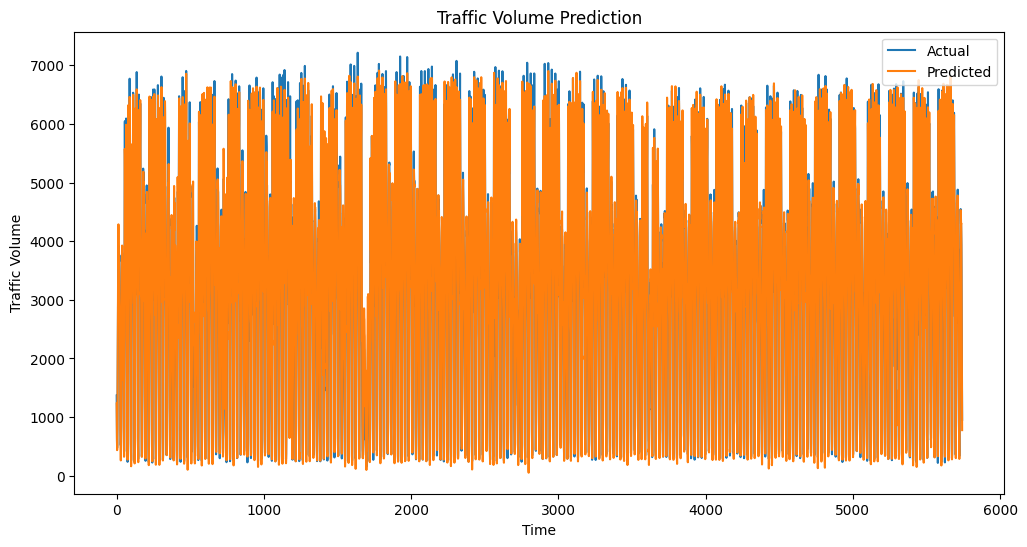

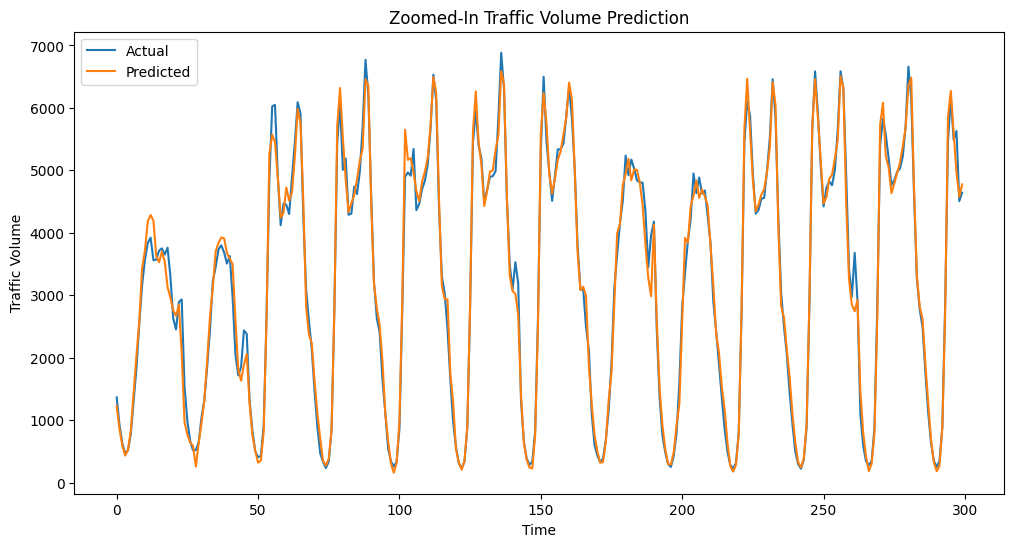

MAE:  168.04
RMSE: 244.14
R²: 0.9848

normalized RMSE by...
mean: 0.0729
range: 0.0346
std: 0.1231


In [39]:
# evaluating trained LSTM model on the testing data
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        output = model(X_batch)

        preds.append(output.cpu().numpy())
        actuals.append(y_batch.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

# reversing the normalization
target_index = features.index(target)

def inverse_transform_target(scaled_values, scaler, num_features, target_index):
    temp = np.zeros((len(scaled_values), num_features))
    temp[:, target_index] = scaled_values.flatten()
    return scaler.inverse_transform(temp)[:, target_index]

preds_inv = inverse_transform_target(preds, scaler, len(features), target_index)
actuals_inv = inverse_transform_target(actuals, scaler, len(features), target_index)


# ploting predictions vs actual, across entire test set
plt.figure(figsize=(12,6))
plt.plot(actuals_inv, label="Actual")
plt.plot(preds_inv, label="Predicted")
plt.title("Traffic Volume Prediction")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()

# plotting on a zoomed-in time slice for visualization purposes
start, end = 0, 300

plt.figure(figsize=(12,6))
plt.plot(actuals_inv[start:end], label="Actual")
plt.plot(preds_inv[start:end], label="Predicted")
plt.title("Zoomed-In Traffic Volume Prediction")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()

# error metrics
mse = mean_squared_error(actuals_inv, preds_inv)
rmse = np.sqrt(mse)

mean = np.mean(actuals_inv)

mae = mean_absolute_error(actuals_inv, preds_inv)
r2 = r2_score(actuals_inv, preds_inv)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

print("\nnormalized RMSE by...")
print(f"mean: {rmse / mean:.4f}")
print(f"range: {rmse / (np.max(actuals_inv) - np.min(actuals_inv)):.4f}")
print(f"std: {rmse / np.std(actuals_inv):.4f}")